In [339]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [340]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# 1. LOAD DATA

In [341]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

print(train.info())
print(test.info())


Train Shape:  (1460, 81)
Test Shape:  (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Ove

# 2. CHECK NULL VALUES

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


<Axes: >

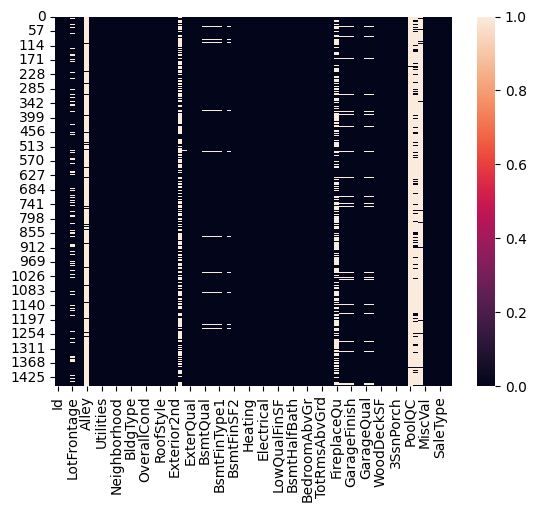

In [342]:
print(train.isnull().sum())
sns.heatmap(train.isnull())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

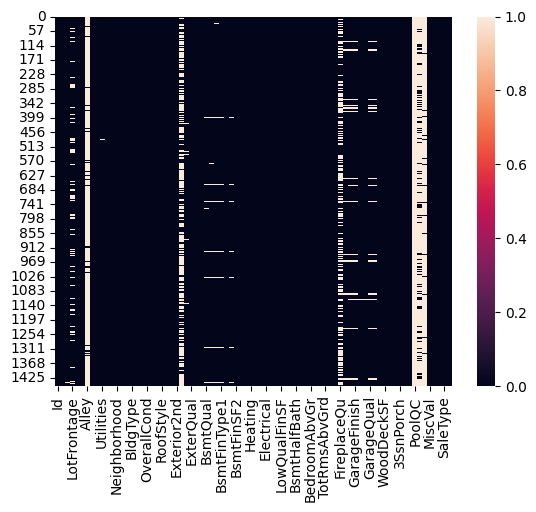

In [343]:
print(test.isnull().sum())
sns.heatmap(test.isnull())

# 3. HANDLE NULL DATA

In [344]:
cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond'
]

ncat_col_train = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea'
]

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())


In [345]:
cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond',
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'Functional', 'SaleType'
]

ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())


Train Shape:  (1460, 76)


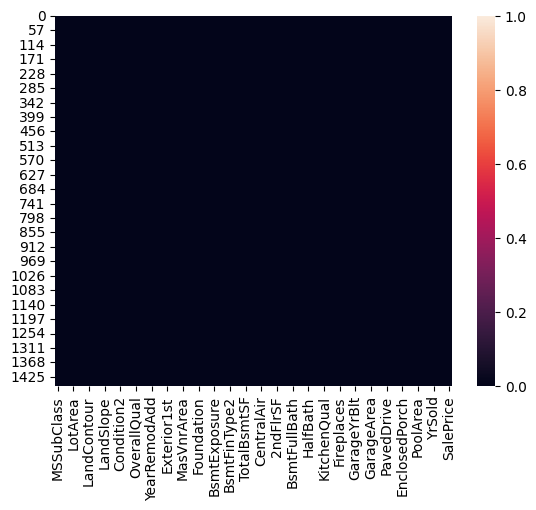

In [346]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train.drop([k], axis=1, inplace=True)
    test.drop([k], axis=1, inplace=True)

sns.heatmap(train.isnull())

print("Train Shape: ", train.shape)

Test Shape:  (1459, 75)


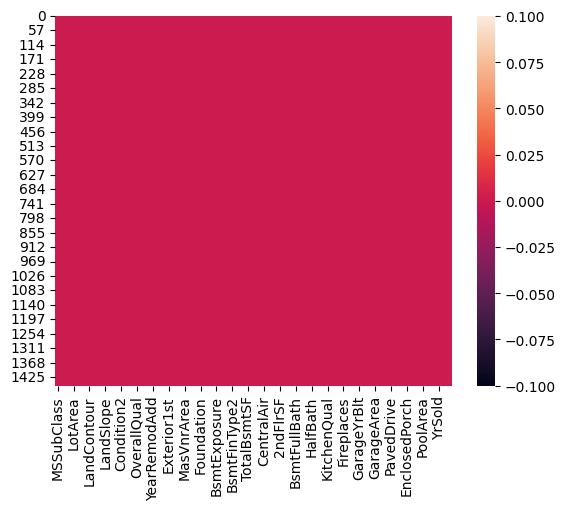

In [347]:
sns.heatmap(test.isnull())
print("Test Shape: ", test.shape)

# 4. CONCAT TRAIN + TEST

In [348]:
final_df = pd.concat([train, test], axis=0)

# 5. ONE-HOT ENCODING

In [349]:
all_cat_col = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
    'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
    'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
    'SaleType', 'SaleCondition'
]


def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0

    for fields in multicol:
        print(fields)

        df1 = pd.get_dummies(
            final_df[fields],
            drop_first=True
        )

        final_df.drop([fields], axis=1, inplace=True)

        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)

        i = i + 1

    df_final = pd.concat([final_df, df_final], axis=1)

    return df_final


final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


# 6. REMOVE DUPLICATED COLUMNS

In [350]:
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

# 7. DIVIDE TRAIN / TEST DATA

In [351]:
df_train = final_df.iloc[:1460, :].copy()
df_test = final_df.iloc[1460:, :].copy()

df_test.drop(['SalePrice'], axis=1, inplace=True)

print("Train Shape: ", df_train.shape)
print("Test Shape: ", df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


# 8. TRAINING DATA

In [352]:
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

# 9. XGBOOST

In [353]:
import xgboost

xgb_model = xgboost.XGBRegressor()
xgb_model.fit(x_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [354]:
param = {
    'n_estimators': [100, 500, 900, 1100, 1500],
    'max_depth': [2, 3, 5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster': ['gbtree'],
    'base_score': [0.25, 0.5, 0.75, 1]
}

from sklearn.model_selection import RandomizedSearchCV

random_cv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param,
    cv=5,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    n_jobs=4,
    verbose=5,
    return_train_score=True,
    random_state=42
)

random_cv.fit(x_train, y_train)

print(random_cv.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 3/5] END base_score=0.75, booster=gbtree, learning_rate=0.2, max_depth=3, min_child_weight=2, n_estimators=500;, score=(train=-2344.570, test=-17439.079) total time=   0.8s
[CV 3/5] END base_score=1, booster=gbtree, learning_rate=0.15, max_depth=5, min_child_weight=4, n_estimators=1500;, score=(train=-4.550, test=-17056.254) total time=   3.9s
[CV 1/5] END base_score=0.75, booster=gbtree, learning_rate=0.05, max_depth=10, min_child_weight=1, n_estimators=100;, score=(train=-2682.938, test=-16382.299) total time=   1.6s
[CV 4/5] END base_score=0.75, booster=gbtree, learning_rate=0.05, max_depth=10, min_child_weight=1, n_estimators=100;, score=(train=-2651.856, test=-15537.291) total time=   1.5s
[CV 2/5] END base_score=1, booster=gbtree, learning_rate=0.05, max_depth=15, min_child_weight=3, n_estimators=1500;, score=(train=-7.185, test=-17085.821) total time=  19.3s
[CV 2/5] END base_score=0.75, booster=gbtree, learning_ra

In [355]:
xgb_model = xgboost.XGBRegressor(
    base_score=0.25,
    booster='gbtree',
    colsample_bylevel=1,
    colsample_bynode=1,
    colsample_bytree=1,
    gamma=0,
    importance_type='gain',
    interaction_constraints='',
    learning_rate=0.1,
    max_delta_step=0,
    max_depth=2,
    min_child_weight=1,
    n_estimators=900,
    n_jobs=0,
    num_parallel_tree=1,
    objective='reg:squarederror',
    random_state=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    subsample=1,
    tree_method='hist',
    validate_parameters=1,
    verbosity=None
)

xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=0.25, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0, grow_policy=None, importance_type='gain',
             interaction_constraints='', learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
             max_depth=2, max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=0, num_parallel_tree=1, ...)

### Save Model 

In [356]:
f = "xgb_model.pkl"
pickle.dump(xgb_model, open(f, 'wb'))

### Predictions

In [357]:
pred_xgb = xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


### Submission

In [358]:
sub_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df['SalePrice'] = pred_xgb
sub_df.to_csv('sample_sub_xgb.csv', index=False)

# 10. DECISION TREE

In [359]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

pred_dt = dt_model.predict(df_test)
print(pred_dt.shape)


(1459,)


### Submission

In [360]:
sub_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
sub_df['SalePrice'] = pred_dt
sub_df.to_csv('submission.csv', index=False)

# 11. ARTIFICIAL NEURAL NETWORK

In [361]:
import keras
from keras import ops
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras import backend as k


def root_mean_squared_error(y_true, y_pred):
    return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))


### Model

In [362]:
nn_model = Sequential()

nn_model.add(
    Dense(
        50,
        kernel_initializer='he_uniform',
        activation='relu',
        input_dim=175
    )
)

nn_model.add(
    Dense(
        25,
        kernel_initializer='he_uniform',
        activation='relu'
    )
)

nn_model.add(
    Dense(
        50,
        kernel_initializer='he_uniform',
        activation='relu'
    )
)

nn_model.add(
    Dense(
        1,
        kernel_initializer='he_uniform'
    )
)


nn_model.compile(
    loss=root_mean_squared_error,
    optimizer='Adamax'
)

x_train = x_train.astype(float)
y_train = y_train.astype(float)

nn_model.fit(
    x_train.values,
    y_train.values,
    validation_split=0.25,
    batch_size=10,
    epochs=100
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 180905.9219 - val_loss: 152910.8750
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 104146.4062 - val_loss: 63299.7539
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67294.7500 - val_loss: 60805.5195
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 65356.4219 - val_loss: 59632.3438
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63272.1758 - val_loss: 58440.2891
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61719.4961 - val_loss: 57549.4258
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 59861.6680 - val_loss: 56303.3164
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 58385.4570 - val_loss: 55772.6016
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 57246.0703 - val_loss: 54258.3086
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 55516.1289 - val_loss: 52976.8203
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

In [363]:
nn_model.save('nn_model.keras')

### Predictions 

In [364]:
pred_nn = nn_model.predict(df_test)

print(pred_nn.shape)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(1459, 1)


### Submission

In [365]:
sub_df = pd.read_csv(
    '/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv'
)

sub_df['SalePrice'] = pred_nn
sub_df.to_csv('submission.csv', index=False)


[CV 1/5] END base_score=0.75, booster=gbtree, learning_rate=0.2, max_depth=3, min_child_weight=2, n_estimators=500;, score=(train=-2512.136, test=-15047.463) total time=   0.8s
[CV 1/5] END base_score=1, booster=gbtree, learning_rate=0.15, max_depth=5, min_child_weight=4, n_estimators=1500;, score=(train=-9.377, test=-15962.865) total time=   3.9s
[CV 5/5] END base_score=1, booster=gbtree, learning_rate=0.15, max_depth=5, min_child_weight=4, n_estimators=1500;, score=(train=-2.802, test=-17658.674) total time=   4.0s
[CV 4/5] END base_score=1, booster=gbtree, learning_rate=0.05, max_depth=15, min_child_weight=3, n_estimators=1500;, score=(train=-7.220, test=-14200.162) total time=  15.7s
[CV 3/5] END base_score=0.75, booster=gbtree, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=100;, score=(train=-8442.721, test=-16856.743) total time=   0.2s
[CV 5/5] END base_score=0.75, booster=gbtree, learning_rate=0.2, max_depth=3, min_child_weight=3, n_estimators=100;, score=(tr